In [1]:
from probjax.distributions import Normal
from probjax.distributions.transformed_distribution import TransformedDistribution
import jax
import jax.numpy as jnp
from probjax.core.custom_primitives.random_variable import rv

from jax.api_util import flatten_fun_nokwargs


import matplotlib.pyplot as plt
key = jax.random.PRNGKey(0)
p = Normal(0, 1)

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [13]:
q = TransformedDistribution(p, lambda x: 2*x + 1)
q_eqiv = Normal(1, 2)

In [14]:
def loss1(x):
    return jnp.sum(q.log_prob(x))

def loss2(x):
    return jnp.sum(q_eqiv.log_prob(x))

In [21]:
jax.grad(loss1)(jnp.ones(2)*2)

Array([-0.25, -0.25], dtype=float32)

In [20]:
jax.grad(loss2)(jnp.ones(2)*2)

Array([-0.25, -0.25], dtype=float32)

In [9]:
import haiku as hk 

hk.transform(lambda x: q.log_prob(x)).init(key, jnp.zeros(1))

{}

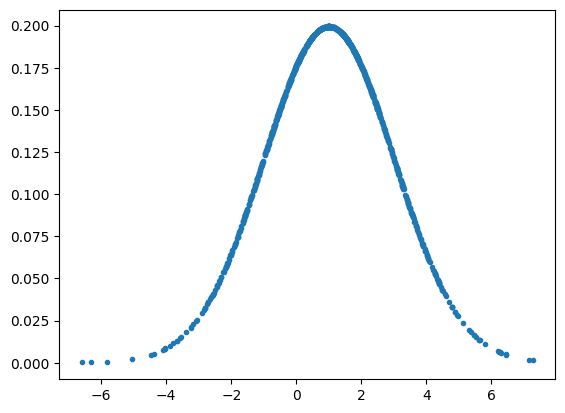

In [10]:
s = q.sample(key, sample_shape=(1000,)).sort()

qs  = q.log_prob(s)


plt.plot(s, jnp.exp(qs), ".")

In [12]:
jnp.trapz(jnp.exp(qs), s)

Array(1., dtype=float32)

In [2]:
x = rv(Normal(0, 1), "x")
y = rv(Normal(0, 1), "y")
key = jax.random.PRNGKey(0)
def f(key):
    out = x(key)**2
    y = rv(Normal(out, 1), "y")(key)
    return y

In [3]:
from probjax.core import joint_sample

sampling = jax.jit(joint_sample(f))

In [4]:
%%timeit
sampling(key)

3.57 µs ± 130 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [5]:
from probjax.core import log_potential_fn

log_potential = jax.jit(log_potential_fn(f, key))

In [6]:
joint_samples = sampling(key)

In [7]:
%%timeit
log_potential(joint_samples)

2.84 µs ± 117 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [9]:
jax.grad(log_potential)(joint_samples)

{'x': Array(0.29058433, dtype=float32), 'y': Array(0.20584226, dtype=float32)}

In [63]:
jaxpr = jax.make_jaxpr(f)(key)

log_prob_fn = jaxpr.eqns[0].params["log_prob_fn_jaxpr"]

In [178]:
from probjax.core.jaxpr_propagation.utils import ForwardProcessingRule

def cost_fn(eqn, in_known, out_known):
    if eqn.primitive is rv_p and all(in_known):
        return 0 
    elif all(in_known): 
        return 1
    else:
        return 2

class LogPotentialProcessingRule(ForwardProcessingRule):
    log_prob: float = 0.0

    def __init__(self, joint_samples):
        self.joint_samples = joint_samples

    def __call__(self, eqn, in_known, out_known):
        if eqn.primitive is rv_p:
            name = eqn.params["name"]
            outvars = eqn.outvars
            outvals = [self.joint_samples[name]]
            in_known[-1] = outvals[0]
            log_prob_fn = eqn.params["log_prob_fn_jaxpr"]
            self.log_prob += jax.core.eval_jaxpr(log_prob_fn.jaxpr, log_prob_fn.consts, *in_known)[0]
        else:
            outvars, outvals = super().__call__(eqn, in_known, out_known)

        return outvars, outvals


In [179]:
?jax.core.eval_jaxpr

Signature:
jax.core.eval_jaxpr(
    jaxpr: 'Jaxpr',
    consts,
    *args,
    propagate_source_info=True,
)
Docstring: <no docstring>
File:      ~/miniconda3/envs/rvtorch/lib/python3.10/site-packages/jax/_src/core.py
Type:      function

In [180]:
import jax
from jax.core import Jaxpr, JaxprEqn, Literal, Var, Atom
from jax._src.util import safe_map as map
from typing import Callable, List, Tuple, Union, Optional, Any
from jaxtyping import Array

import math

from probjax.utils.containers import PriorityQueue
from probjax.core.jaxpr_propagation.utils import (
    Environment,
    construct_jaxpr_graph,
    ForwardProcessingRule,
    ProcessingRule,
)


# Jaxpr are usually processed in a topological order. But we need to process it in a custom order.
# Hence this gives use a general propagation algorithm!


def naive_cost_fn(
    eqn: JaxprEqn, is_known_invars: List[bool], is_known_outvars: List[bool]
) -> float:
    """A naive cost function that returns 0 if all inputs are known and inf otherwise.
    This cost function is used for the forward pass. We can only compute the equation if all inputs are known.

    Args:
        eqn (JaxprEqn): JaxprEqn object.
        is_known_invars (List[bool]): List of booleans indicating whether the input variables are known.
        is_known_outvars (List[bool]): List of booleans indicating whether the output variables are known.

    Returns:
        float: Cost of the equation.
    """
    if all(is_known_invars):
        return 0.0
    else:
        return math.inf


class EqnEnvironment:
    """This class implements a priority queue for equations. The priority is determined by the cost function."""

    env: Environment
    eqn_queue: PriorityQueue

    def __init__(
        self,
        G: dict,
        env: Environment,
        eqns: List[JaxprEqn],
        cost_fn: Callable = naive_cost_fn,
    ):
        self.G = G
        self.env = env
        self.eqns = eqns
        self.eqn_queue = PriorityQueue()
        self.processed_eqns = set()
        self.cost_fn = cost_fn

        self._init_eqn_queue()

    def _init_eqn_queue(self):
        for v in self.env:
            eqns_index = self.G[v]
            map(self.write, eqns_index)

    def write(self, index: int):
        if index in self.processed_eqns:
            # Do not write processed equations
            return
        if index in self.eqn_queue:
            # Remove equation from the queue if it is already present
            eqn = self.eqns[index]
            known_invars = map(self.env.known, eqn.invars)
            known_outvars = map(self.env.known, eqn.outvars)
            cost = self.cost_fn(eqn, known_invars, known_outvars)
            self.eqn_queue.update_cost(index, cost)
            return
        # Write equation to the queue
        eqn = self.eqns[index]
        known_invars = map(self.env.known, eqn.invars)
        known_outvars = map(self.env.known, eqn.outvars)
        cost = self.cost_fn(eqn, known_invars, known_outvars)
        self.eqn_queue.insert(index, cost)

    def pop(self) -> JaxprEqn:
        index = self.eqn_queue.pop()
        eqn = self.eqns[index]
        self.processed_eqns.add(index)
        return eqn

    def is_empty(self) -> bool:
        return self.eqn_queue.is_empty()


# TODO: We have to add call this recursively for nested jaxprs.


def propagate(
    jaxpr: Jaxpr,
    consts: List[Array],
    invars: List[Var],
    inputs: List[Array],
    outvars: List[Var],
    process_eqn: ProcessingRule
    | Callable[
        [JaxprEqn, List[Optional[Array]], List[Optional[Array]]], Tuple[List[Var], Any]
    ] = ForwardProcessingRule(),
    cost_fn: Callable = naive_cost_fn,
) -> List[Optional[Array]]:
    """This implements a general propagation algorithm for JaxPr.

    Args:
        jaxpr (Jaxpr): Jaxpr object.
        consts (List[Array]): Constants.
        invars (List[Var]): Input variables.
        inputs (List[Array]): Input data.
        outvars (List[Var]): Output variables.
        process_eqn (Callable[ [JaxprEqn, List[Optional[Array]], List[Optional[Array]]], Tuple[List[Var], List[Array]], ]): Function that processes the equation.
        cost_fn (Callable, optional): Cost function to prioritize the evaluation order!. Defaults to naive_cost_fn.

    Returns:
        List[Optional[Array]]: _description_
    """

    # Set up environment
    env = Environment()

    G = construct_jaxpr_graph(jaxpr)

    map(env.write, jaxpr.constvars, consts)
    map(env.write, invars, inputs)

    # Set up equations
    eqn_env = EqnEnvironment(G, env, jaxpr.eqns, cost_fn)

    while not eqn_env.is_empty():
        
        print(env)
        eqn = eqn_env.pop()  # Equation to process

        # Read known invars and outvars
        known_invars = map(env.read, eqn.invars)
        known_outvars = map(env.read, eqn.outvars)

        # This processes the computation
        ouput_vars, output_vals = process_eqn(eqn, known_invars, known_outvars)

        # Write outvars
        map(env.write, ouput_vars, output_vals)

        # Update reachable equations
        for v in ouput_vars:
            eqns_index = G[v]
            map(eqn_env.write, eqns_index)

        if all(map(env.known, outvars)):
            break

    # Gather target values
    out = map(env.read, outvars)

    return out


In [181]:
from probjax.core.custom_primitives.random_variable import rv_p


def extract_random_vars_values(jaxpr, joint_samples):

    vars = []
    vars_inputs = []
    values = []

    for eqn in jaxpr.eqns:
        if eqn.primitive is rv_p:
            name = eqn.params["name"]
            invars = [v for v in eqn.invars if not (isinstance(v, jax.core.Literal))]
            outvars = eqn.outvars
            vars.append(eqn.outvars[0])
            values.append(joint_samples[name])

            vars_inputs.extend(invars)


    return vars, vars_inputs, values

rv_vars, rv_vars_inputs, rv_values = extract_random_vars_values(jaxpr, joint_samples)




In [182]:
jaxpr

{ lambda a:i32[] b:i32[]; c:u32[2]. let
    d:f32[] = random_variable[
      dist=<class 'probjax.distributions.normal.Normal'>
      log_prob_fn_jaxpr={ lambda ; e_:i32[] f_:i32[] g:i32[] h:i32[] i:f32[]. let
          j:f32[] = convert_element_type[new_dtype=float32 weak_type=False] g
          k:f32[] = convert_element_type[new_dtype=float32 weak_type=False] h
          l:f32[] = integer_pow[y=2] k
          m:f32[] = mul 6.2831854820251465 l
          n:f32[] = log m
          o:f32[] = sub i j
          p:f32[] = integer_pow[y=2] o
          q:f32[] = div p l
          r:f32[] = add n q
          s:f32[] = div r -2.0
        in (s,) }
      name=x
      sampling_fn_jaxpr={ lambda ; t:i32[] u:i32[] v_:i32[] w_:i32[] x:u32[2]. let
          y:key<fry>[] = random_wrap[impl=fry] x
          z:u32[] = random_bits[bit_width=32 shape=()] y
          ba:u32[] = shift_right_logical z 9
          bb:u32[] = or ba 1065353216
          bc:f32[] = bitcast_convert_type[new_dtype=float32] bb
   

In [183]:
jaxpr.eqns[-1].outvars

[f]

In [184]:
rule = LogPotentialProcessingRule(joint_samples)
propagate(jaxpr.jaxpr, jaxpr.consts, [], [],  rv_vars, process_eqn=rule, cost_fn=cost_fn)

{a: Array(1, dtype=int32, weak_type=True), b: Array(0, dtype=int32, weak_type=True)}
{a: Array(1, dtype=int32, weak_type=True), b: Array(0, dtype=int32, weak_type=True), d: Array(-0.20584226, dtype=float32)}
{a: Array(1, dtype=int32, weak_type=True), b: Array(0, dtype=int32, weak_type=True), d: Array(-0.20584226, dtype=float32), e: Array(0.04237103, dtype=float32)}


[Array(-0.20584226, dtype=float32), Array(-0.16347122, dtype=float32)]

In [186]:
rule.log_prob

Array(-1.8802481, dtype=float32)

In [112]:
?propagate

Signature:
propagate(
    jaxpr: jax._src.core.Jaxpr,
    consts: List[jax.Array],
    invars: List[jax._src.core.Var],
    inputs: List[jax.Array],
    outvars: List[jax._src.core.Var],
    process_eqn: Union[probjax.core.jaxpr_propagation.utils.ProcessingRule, Callable[[jax._src.core.JaxprEqn, List[jax.Array | None], List[jax.Array | None]], Tuple[List[jax._src.core.Var], Any]]] = <probjax.core.jaxpr_propagation.utils.ForwardProcessingRule object at 0x7f0ce5fbbd30>,
    cost_fn: Callable = <function naive_cost_fn at 0x7f0ce6099e10>,
) -> List[jax.Array | None]
Docstring:
This implements a general propagation algorithm for JaxPr.

Args:
    jaxpr (Jaxpr): Jaxpr object.
    consts (List[Array]): Constants.
    invars (List[Var]): Input variables.
    inputs (List[Array]): Input data.
    outvars (List[Var]): Output variables.
    process_eqn (Callable[ [JaxprEqn, List[Optional[Array]], List[Optional[Array]]], Tuple[List[Var], List[Array]], ]): Function that processes the equation.
    

In [76]:
from probjax.core.jaxpr_propagation.interpret import interpret
from probjax.core.jaxpr_propagation.propagate import propagate
#from probjax.core.interpreters.joint_sample import JointSampleProcessingRule

In [53]:
rv_vars_inputs

[a, 1]

In [52]:
propagate(jaxpr.jaxpr, jaxpr.consts, rv_vars, [jax.numpy.ones(1), jax.numpy.ones(1)], rv_vars_inputs)

TypeError: JAX encountered invalid PRNG key data: expected key_data to have ndim, shape, and dtype attributes. Got None

In [45]:
?propagate

Signature:
propagate(
    jaxpr: jax._src.core.Jaxpr,
    consts: List[jax.Array],
    invars: List[jax._src.core.Var],
    inputs: List[jax.Array],
    outvars: List[jax._src.core.Var],
    process_eqn: Union[probjax.core.jaxpr_propagation.utils.ProcessingRule, Callable[[jax._src.core.JaxprEqn, List[jax.Array | None], List[jax.Array | None]], Tuple[List[jax._src.core.Var], Any]]] = <probjax.core.jaxpr_propagation.utils.ForwardProcessingRule object at 0x7f0e1c328970>,
    cost_fn: Callable = <function naive_cost_fn at 0x7f0d0ed776d0>,
) -> List[jax.Array | None]
Docstring:
This implements a general propagation algorithm for JaxPr.

Args:
    jaxpr (Jaxpr): Jaxpr object.
    consts (List[Array]): Constants.
    invars (List[Var]): Input variables.
    inputs (List[Array]): Input data.
    outvars (List[Var]): Output variables.
    process_eqn (Callable[ [JaxprEqn, List[Optional[Array]], List[Optional[Array]]], Tuple[List[Var], List[Array]], ]): Function that processes the equation.
    

In [18]:
joint_sample_rule = JointSampleProcessingRule()
interpret(jaxpr.jaxpr, jaxpr.consts, jaxpr.jaxpr.invars, [jax.random.PRNGKey(0)], jaxpr.jaxpr.outvars, process_eqn=joint_sample_rule)

NameError: name 'jaxpr' is not defined

In [19]:
joint_sample_rule.joint_samples

{'x': Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=1/0)>,
 'y': Traced<ShapedArray(float32[])>with<DynamicJaxprTrace(level=1/0)>}

In [20]:


def sample_fn(key, *args, **kwargs):
        return _sample_distribution(p, key, *args, **kwargs)

def log_prob_fn(value, *args, **kwargs):
    return _log_prob_distribution(p, value, *args, **kwargs)

sampling_fn = sample_fn
wrapped_sampling_fn = lu.wrap_init(sampling_fn)
in_avals = [
    ShapedArray((2,), jax.numpy.uint32),
]  # The PRNG Key!
in_tree = tree_util.tree_structure(in_avals)
jax_tree_fun, out_tree = flatten_fun_nokwargs(wrapped_sampling_fn, in_tree)
debug = pe.debug_info(sampling_fn, None, None, False, "sampling_fn")

sampling_jaxpr, sampling_out_avals, sampling_consts = pe.trace_to_jaxpr_dynamic(
    jax_tree_fun, in_avals, debug
)

NameError: name 'lu' is not defined

In [3]:
from jax.core import (
    Primitive,
    ClosedJaxpr,
    new_sublevel,
    eval_jaxpr,
    ShapedArray,
)

import jax
import jax.random as jrandom
from jax import tree_util
from jax import linear_util as lu
from jax._src import api_util
from jax._src import util
from typing import Hashable, Callable
from jax._src import effects
from jax.interpreters import ad
from jax.interpreters import batching
from jax.interpreters import mlir
from jax.interpreters.batching import batch_jaxpr
from jax.interpreters import partial_eval as pe

from jax._src.util import safe_map as map

from functools import partial


from probjax.distributions.distribution import Distribution

__all__ = ["rv"]


def _sample_distribution(dist: Distribution, key, *args, shape=(), **kwargs):
    return dist.sample(key, *args, sample_shape=shape, **kwargs)


def _log_prob_distribution(dist: Distribution, value, *args, **kwargs):
    return dist.log_prob(value=value, *args, **kwargs)


@util.cache()
def _sampling_logprobs_jaxprs_with_common_consts(sampling_fn, log_prob_fn):
    wrapped_sampling_fn = lu.wrap_init(sampling_fn)
    in_avals = [
        ShapedArray((2,), jax.numpy.uint32),
    ]  # The PRNG Key!
    debug = pe.debug_info(sampling_fn, None, None, False, "sampling_fn")
    sampling_jaxpr, sampling_out_avals, sampling_consts = pe.trace_to_jaxpr_dynamic(
        wrapped_sampling_fn, in_avals, debug
    )

    wrapped_log_prob_fn = lu.wrap_init(log_prob_fn)
    log_prob_operands = sampling_out_avals
    # log_prob_ops, log_prob_ops_tree = tree_flatten(log_prob_operands)
    debug = pe.debug_info(log_prob_fn, None, None, False, "log_prob_fn")
    log_prob_jaxpr, log_prob_out_avals, log_prob_consts = pe.trace_to_jaxpr_dynamic(
        wrapped_log_prob_fn, sampling_out_avals, debug
    )

    jaxprs = [sampling_jaxpr, log_prob_jaxpr]
    consts = [sampling_consts, log_prob_consts]
    # out_trees = [sampling_out_trees, log_prob_out_trees]

    newvar = jax._src.core.gensym(jaxprs, suffix="_")
    all_const_avals = [map(api_util.shaped_abstractify, consts) for consts in consts]
    unused_const_vars = [map(newvar, const_avals) for const_avals in all_const_avals]

    def pad_jaxpr_constvars(i, jaxpr):
        prefix = util.concatenate(unused_const_vars[:i])
        suffix = util.concatenate(unused_const_vars[i + 1 :])
        constvars = [*prefix, *jaxpr.constvars, *suffix]
        return jaxpr.replace(constvars=constvars)

    consts = util.concatenate(consts)
    jaxprs = tuple(pad_jaxpr_constvars(i, jaxpr) for i, jaxpr in enumerate(jaxprs))
    closed_jaxprs = [
        ClosedJaxpr(pe.convert_constvars_jaxpr(jaxpr), ()) for jaxpr in jaxprs
    ]

    return closed_jaxprs, consts


def rv(dist: Distribution, name: Hashable) -> Callable:
    """This takes a distribution and returns a function that samples from that distribution.


    Args:
        dist (Distribution): Distribution of random variable
        name (Hashable): Name of random variable

    Returns:
        Callable: Sampling function
    """

    def sample_fn(key, *args, **kwargs):
        return _sample_distribution(dist, key, *args, **kwargs)

    def log_prob_fn(value, *args, **kwargs):
        return _log_prob_distribution(dist, value, *args, **kwargs)

    (
        [sampling_fn_jaxpr, log_prob_fn_jaxpr],
        consts,
    ) = _sampling_logprobs_jaxprs_with_common_consts(sample_fn, log_prob_fn)

    def wrapped(*args, **kwargs):
        out = rv_p.bind(
            *consts,
            *args,
            name=name,
            sampling_fn_jaxpr=sampling_fn_jaxpr,
            log_prob_fn_jaxpr=log_prob_fn_jaxpr,
            dist=type(dist),
            **kwargs
        )

        return out[0]

    return wrapped


def _rv_impl(*args, **params):
    with new_sublevel():
        call_jaxpr = params.get("sampling_fn_jaxpr")
        return eval_jaxpr(call_jaxpr.jaxpr, call_jaxpr.literals, *args)


def _rv_abstract_eval(*args, **params):
    with new_sublevel():
        call_jaxpr = params.get("sampling_fn_jaxpr")
        return call_jaxpr.out_avals


# JIT support
def _rv_lowering(ctx, *args, name, sampling_fn_jaxpr, log_prob_fn_jaxpr, **params):
    call_jaxpr = sampling_fn_jaxpr
    return mlir.core_call_lowering(ctx, *args, name=name, call_jaxpr=call_jaxpr)


def _rv_transpose_rule(*args, **kwargs):
    return ad.call_transpose(rv_p, *args, **kwargs)


def _rv_batching_rule(
    spmd_axis_name, axis_size, axis_name, main_type, args, dims, **params
):
    sampling_fn_jaxpr = params.pop("sampling_fn_jaxpr")
    log_prob_fn_jaxpr = params.pop("log_prob_fn_jaxpr")

    # We have to batch the jaxprs. For that lets first get the invals and outvals
    in_avals1 = sampling_fn_jaxpr.in_avals
    out_avals1 = sampling_fn_jaxpr.out_avals

    in_avals2 = log_prob_fn_jaxpr.in_avals
    out_avals2 = log_prob_fn_jaxpr.out_avals

    # We will batch all the inputs and outputs  (maybe do not batch consts ... )
    in_batched1 = [True] * len(in_avals1)
    out_batched1 = [True] * len(out_avals1)

    in_batched2 = [True] * len(in_avals2)
    out_batched2 = [True] * len(out_avals2)

    # Applies the batching for the jaxprs
    args = [batching.bdim_at_front(x, d, axis_size) for x, d in zip(args, dims)]

    # Batched jaxprs
    batched_sampling_fn, out_size1 = batch_jaxpr(
        sampling_fn_jaxpr,
        axis_size,
        in_batched1,
        out_batched1,
        axis_name,
        spmd_axis_name,
        main_type,
    )
    batched_log_prob_fn, _ = batch_jaxpr(
        log_prob_fn_jaxpr,
        axis_size,
        in_batched2,
        out_batched2,
        axis_name,
        spmd_axis_name,
        main_type,
    )

    # Update jaxprs with batched ones
    out = rv_p.bind(
        *args,
        sampling_fn_jaxpr=batched_sampling_fn,
        log_prob_fn_jaxpr=batched_log_prob_fn,
        **params
    )

    # Outdim
    out_dims = [0 if b else batching.not_mapped for b in out_size1]

    return out, out_dims


rv_p = Primitive("random_variable")
rv_p.multiple_results = True
rv_p.def_impl(_rv_impl)
rv_p.def_abstract_eval(_rv_abstract_eval)
batching.spmd_axis_primitive_batchers[rv_p] = _rv_batching_rule
batching.axis_primitive_batchers[rv_p] = partial(_rv_batching_rule, None)
mlir.register_lowering(rv_p, _rv_lowering)
ad.primitive_transposes[rv_p] = _rv_transpose_rule
